## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [25]:
# importar librerías
import pandas as pan
import numpy as num
import seaborn as sea
import matplotlib.pyplot as mat



In [26]:
# cargar archivos
traffic = pan.read_csv('/datasets/tomtom_traffic.csv')
eco = pan.read_csv('/datasets/oecd_city_economy.csv')

In [27]:
# mostrar las primeras 5 filas de traffic
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [28]:
# mostrar las primeras 5 filas de eco
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Tip:** Si no usas `print()` la tabla se vera mejor.

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [29]:
# Examinar la estructura de traffic
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype



En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo object
- Se tiene que pasar a datetime



In [30]:
# Examinar la estructura de eco
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB



En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, `PM2.5 (μg/m³)` y `Population (M)` estan como object
- Se deben de cambiar a float

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `City` → `city`
    - `UpdateTimeUTC` → `update_time_utc`
    - `JamsDelay` → `jams_delay`
    - `TrafficIndexLive` → `traffic_index_live`
    - `JamsLengthInKms` → `jams_length_in_kms`
    - `JamsCount` → `jams_count`
    - `TrafficIndexWeekAgo` → `traffic_index_week_ago`
    - `UpdateTimeUTCWeekAgo` → `update_time_UTC_week_ago`
    - `TravelTimeLivePer10KmsMins` → `travel_time_live_per10kms_mins`
    - `TravelTimeHistoricPer10KmsMins` → `travel_time_hist_per10kms_mins`
    - `MinsDelay` → `mins_delay`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [31]:
# Estandarizar los nombres de las columnas de traffic
traffic.columns=["country","city","update_time_utc","jams_delay","traffic_index_live","jams_length_in_kms","jams_count","traffic_index_week_ago","update_time_UTC_week_ago","travel_time_live_per10kms_mins","travel_time_hist_per10kms_mins","mins_delay"]

# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_UTC_week_ago',
       'travel_time_live_per10kms_mins', 'travel_time_hist_per10kms_mins',
       'mins_delay'],
      dtype='object')

In [32]:
# Estandarizar los nombres de las columnas de eco
eco.columns=["year","city","country","city_gdp_capita","unemployment_%","pm2.5","population"]

# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_%', 'pm2.5',
       'population'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [33]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pan.to_datetime(traffic['update_time_utc'], errors='coerce')
traffic['update_time_utc_week_ago'] = pan.to_datetime(traffic['update_time_UTC_week_ago'], errors='coerce')

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 13 columns):
 #   Column                          Non-Null Count    Dtype         
---  ------                          --------------    -----         
 0   country                         1004464 non-null  object        
 1   city                            1004464 non-null  object        
 2   update_time_utc                 1004464 non-null  datetime64[ns]
 3   jams_delay                      1004464 non-null  float64       
 4   traffic_index_live              1004464 non-null  float64       
 5   jams_length_in_kms              1004464 non-null  float64       
 6   jams_count                      1004464 non-null  float64       
 7   traffic_index_week_ago          1004464 non-null  float64       
 8   update_time_UTC_week_ago        1004464 non-null  object        
 9   travel_time_live_per10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per10kms_mins  1004464 no

In [34]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_%'] = eco['unemployment_%'].astype(str).str.replace('%', '').astype(float)
eco['pm2.5'] = eco['pm2.5'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['population'] = eco['population'].astype(str).str.replace(',', '.').astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population']*1000000

# verificar el cambio
eco.info()
eco.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             30 non-null     int64  
 1   city             30 non-null     object 
 2   country          30 non-null     object 
 3   city_gdp_capita  30 non-null     float64
 4   unemployment_%   30 non-null     float64
 5   pm2.5            30 non-null     float64
 6   population       30 non-null     float64
dtypes: float64(4), int64(1), object(2)
memory usage: 1.8+ KB


,year,city,country,city_gdp_capita,unemployment_%,pm2.5,population
0,2023,buenos-aires,Argentina,15782.0,6.2,15.2,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,29.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,19.1,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [75]:


# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)



,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_UTC_week_ago,travel_time_live_per10kms_mins,travel_time_hist_per10kms_mins,mins_delay,update_time_utc_week_ago,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025-01-06 04:01:30.000,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025-01-06 03:46:30.001,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025-01-06 02:46:30.000,2025


In [76]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic["year"] == 2024].copy()
eco_2024 = eco[eco["year"] == 2024].copy().reset_index()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_UTC_week_ago,travel_time_live_per10kms_mins,travel_time_hist_per10kms_mins,mins_delay,update_time_utc_week_ago,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024-12-24 23:01:30.001,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024-12-24 22:01:30.000,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024-12-24 21:01:30.000,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024-12-24 20:01:30.001,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024-12-24 19:01:00.000,2024


,index,year,city,country,city_gdp_capita,unemployment_%,pm2.5,population
0,15,2024,buenos-aires,Argentina,18117.0,7.2,14.5,15400000.0
1,16,2024,sao-paulo,Brazil,14703.0,8.5,28.0,22600000.0
2,17,2024,rio-de-janeiro,Brazil,13349.0,9.2,18.4,13700000.0
3,18,2024,brasilia,Brazil,16251.0,7.8,12.8,4800000.0
4,19,2024,salvador,Brazil,8899.0,12.4,15.2,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [77]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 =  traffic_2024.groupby(by=["country","city"])["country","city","year","jams_delay","traffic_index_live","jams_length_in_kms","jams_count","mins_delay","travel_time_live_per10kms_mins","travel_time_hist_per10kms_mins"].agg("mean").reset_index()

# Mostrar resultado
traffic_2024.head(3)
traffic_city_year_2024.head(3)

,country,city,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per10kms_mins,travel_time_hist_per10kms_mins
0,ARE,abu-dhabi,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
1,ARE,al-ain,2024,43.119862,11.698618,4.533290,12.623489,0.161476,10.630736,10.469260
2,ARE,dubai,2024,1265.685376,31.214624,189.540172,312.892473,0.848248,12.237314,11.389066


### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares.

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas?

In [79]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,country,city,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per10kms_mins,travel_time_hist_per10kms_mins
222,MEX,mexico-city,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
217,JPN,tokyo,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
352,USA,new-york,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
163,GBR,london,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
252,PHL,manila,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
247,NZL,dunedin,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
284,SWE,uppsala,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
3,ARE,fujairah,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
224,NLD,almere,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es la CDMX (México City)

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [118]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_count','mins_delay',
             'travel_time_live_per10kms_mins','travel_time_hist_per10kms_mins']
right_cols = ['city','year','city_gdp_capita','unemployment_%','pm2.5','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
traffic_2024_small.head(3)
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pan.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')

# Mostrar las primeras 5 filas
merged.head(5)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per10kms_mins,travel_time_hist_per10kms_mins,city_gdp_capita,unemployment_%,pm2.5,population
0,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,14.5,15400000.0
1,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,16.8,6100000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,12.8,4800000.0
3,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,13.5,3700000.0
4,fortaleza,BRA,2024,82.813181,15.896749,11.205844,24.644991,0.081618,19.267171,19.185554,8512.0,11.8,14.6,4200000.0



---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

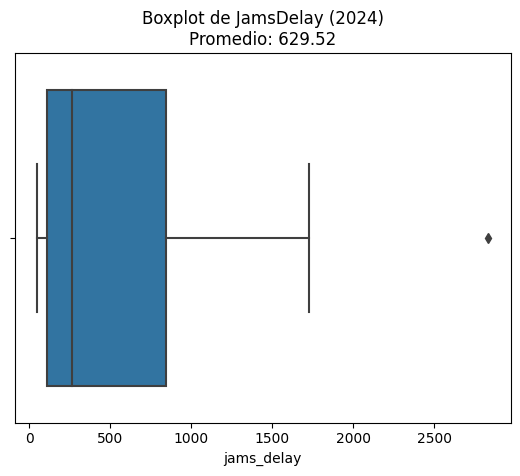

In [110]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
sea.boxplot(data=merged, x='jams_delay')
mat.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
mat.show()


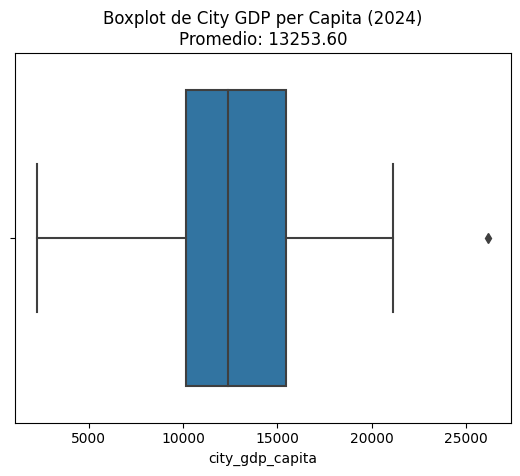

In [111]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
mean_city_value = merged['city_gdp_capita'].mean()
sea.boxplot(data=merged, x='city_gdp_capita')
mat.title(f'Boxplot de City GDP per Capita (2024)\nPromedio: {mean_city_value:.2f}')
mat.show()


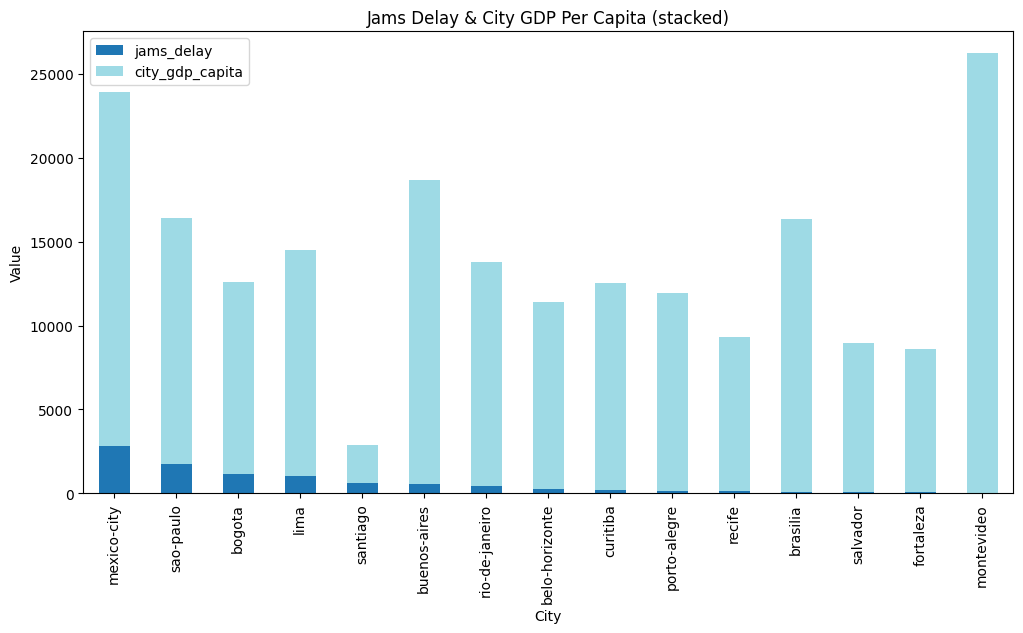

In [135]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged[["city","jams_delay","city_gdp_capita"]].set_index("city").sort_values(by=["jams_delay","city_gdp_capita"],ascending=False).plot( kind="bar", stacked=True, figsize=(12,6), colormap="tab20", y=['jams_delay', 'city_gdp_capita'])
mat.xticks(rotation=90)
mat.title("Jams Delay & City GDP Per Capita (stacked)")
mat.ylabel("Value")
mat.xlabel("City")
mat.show()


**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?
Si en casi todas las ciudades la relación existe muy clara con la excepción de Montevideo la cual tiene bajo el número de Congestionammientos de tráfico.

* ¿O sucede lo contrario, o no existe una relación clara?
De acuerdo con los datos obtenidos y quitando las ciudades en la que no se pudo tener información fidedigna todas las demás ciudades cumplen directamente el factor PIB - Congestionamientos de tráfico, teniendo una alza directamente relacionada.

Para este ejercicio se ve directamente la relación PIB - Congestionamientos teniendo como resultado que entre más PIB existe en una ciudad mas congestionamientos de tráfico hay, esto teniendo la excepción de Montevideo.

Escribe tus comentarios: Se tendrían que confirmar estos números sobre todo en lo que respecta a Montevideo ya que parece una tendencia que entre mas PIB hay en una ciudad más congestionamientos existen. De ser esto cierto entonces hay que tomar el programa que esta implementando Montevideo en cuanto a su política de movilidad para emularla en las ciudades que se pueda.


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [119]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información. 


---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).



---

# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**  
- Se trabaja con los datos de tráfico y PIB para el año 2024, la  relación directa es que cada ciudad tiene un PIB de acuerdo a la población y la productividad per capita.
- El objetivo es adecuar los datos para que la relación se pueda concretar y esta nos explique gráficamente que patrones cumple esta y que datos nos servirán para emitir una resolución.
  
**Cobertura de datos:**  
- Se delimitarán los datos solo al año 2024 y en concreto las 15 ciudades latinoamericanas más imortantes.

**Metodología (alto nivel):**  
- Se realiza una limpieza general de los datos como renombrar los datos existentes para evitar cinfuciones en el proceso. Además se cambian los tipos de datos de fecha y númmero para alistarlos.
- Se saca de la fecha de captura el año en el caso de los datos de tráfico, y se extrae solo el año que nos atañe.
- Se extrae el promedio de la información por ciudad para tener un solo dato, se quitan columnas no necesarias y se realiza una unión de las dos fuentes para cruzar la información, se verifica la información cruzada con una disperción de las dos fuentes.
- Se realizan la gráfica final de comparativa de los resultados.

**Hallazgos iniciales:**  
- Se obtiene de acuerdo a la información analizada algunas ciudades necesitan mayor inversión en infraestructura destacando la Ciudad de México, Sao Paulo y Bogotá.

**Recomendaciones**  
Se sugiere que se canalice inmediatamente más recursos a la infraestructura de transporte en las siguientes ciudades México, Sao Paulo, Bogotá, Lima, Santiago y Buenos Aires. Puntualizando y siendo más urgente en México, Sao Paulo y Bogotá considerando que hay más PIB afectado por los congestionamientos.
- Se considera de acuerdo a los datos que las ciudades de Montevideo y Brazilia estan realizando un excelente trabajo de inversión en infraestructura y muy viables para considerar una inversion en ellas debido a que la inversion en infraestructura se está realizando puntualmente.
- Se podria considerar a Brasil y El Salvador como unas alternativas de inversión ya que aunque los niveles de PIB son bajos estan realizando un buen trabajo para que los niveles de congestionamientos viales son también bajos.
